In [1]:
from roctet import calc_roctet
from roctet.utils import auroc
from numpy import arange
import polars as pl
from plotnine import (ggplot, aes, geom_line, theme_set, theme_bw)

In [2]:
theme_set(theme_bw())

## Data Generation

In [3]:
# generate datasets
dfs = calc_roctet(0.67, n_sets = 10) # 0.82
dfs[0].glimpse()

Rows: 100000
Columns: 7
$ score_min <f64> 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999
$ score_max <f64> 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
$ n_pos     <i64> 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463
$ n_neg     <i64> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50
$ n         <i64> 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513
$ score     <f64> 0.9989990151024222, 0.9989993020887268, 0.9989993334399722, 0.9989994075742544, 0.9989994537046667, 0.9989995165835739, 0.9989996983518074, 0.9989999304951862, 0.9990001276053028, 0.9990001947304734
$ target    <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1



In [4]:
# consolidate to one dataset
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )

## ROC Summary

In [5]:
# compare AUC values
[ auroc(d['target'].to_numpy(), d['score'].to_numpy()) for d in dfs]

[0.6714, 0.6716, 0.6707, 0.6708, 0.6685, 0.6678, 0.6689, 0.6708, 0.6698, 0.67]

## ROC Curves

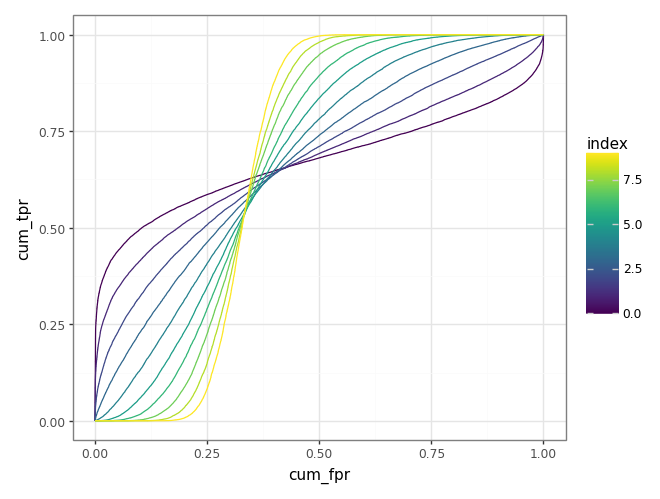

In [6]:
# compute and display roc curve
df_roc = (
    df
    .sort('score', descending=True)
    .with_columns(
        neg_target = 1 - pl.col('target'),
        neg_target_ttl = (1 - pl.col('target')).sum().over('index'),
        pos_target = pl.col('target'),
        pos_target_ttl = pl.col('target').sum().over('index')
        )
    .with_columns(
        cum_fpr = pl.col('neg_target').cum_sum().over('index') / pl.col('neg_target_ttl'),
        cum_tpr = pl.col('pos_target').cum_sum().over('index') / pl.col('pos_target_ttl'),
    )
)

p = ggplot(df_roc)
p += aes(x = 'cum_fpr', y = 'cum_tpr', color = 'index', group = 'index')
p += geom_line()
p

## Lift Charts

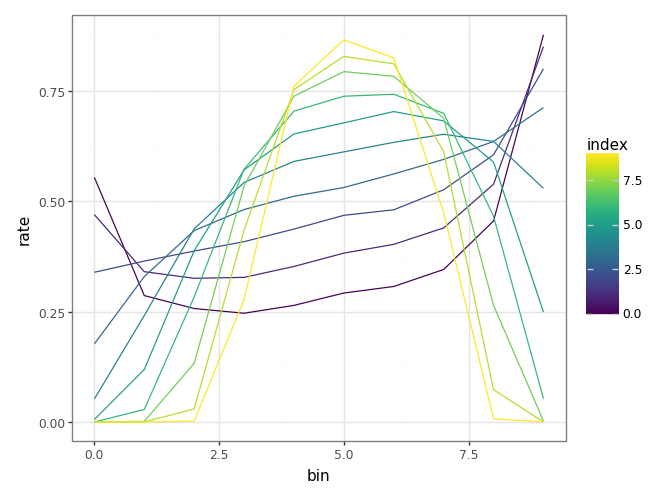

In [7]:
# visualize lift curves
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )
df_lift = (
    df
    .group_by( 'index', 
               bin = pl.col('score').qcut(10, labels = arange(10).astype(str)).cast(pl.String).cast(pl.Int16) 
             )
    .agg( rate = pl.col('target').mean() )
)
p = ggplot(df_lift)
p += aes(x = 'bin', y = 'rate', color = 'index', group = 'index')
p += geom_line()
p